In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt 

In [8]:
data = pd.read_csv('https://stats.idre.ucla.edu/stat/data/binary.csv')
data = data.rename(columns={'rank': 'prestige'})
print(data.shape)
data.head() 

(400, 4)


,admit,gre,gpa,prestige
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [9]:
data.isnull().sum() 

admit       0
gre         0
gpa         0
prestige    0
dtype: int64

In [10]:
data['admit'].value_counts() 

admit
0    273
1    127
Name: count, dtype: int64

In [12]:
feature_cols = ['gre', 'gpa', 'prestige']
x = data[feature_cols]
y = data['admit'] 

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape) 

(320, 3) (320,) (80, 3) (80,)


In [15]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test) 

In [16]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix : ', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100), '%')
print('\n', metrics.classification_report(y_test, y_pred)) 

Confusion Matrix :  [[50  4]
 [23  3]]
Accuracy Score :  0.6625
Accuracy in Percentage :  66 %

               precision    recall  f1-score   support

           0       0.68      0.93      0.79        54
           1       0.43      0.12      0.18        26

    accuracy                           0.66        80
   macro avg       0.56      0.52      0.48        80
weighted avg       0.60      0.66      0.59        80



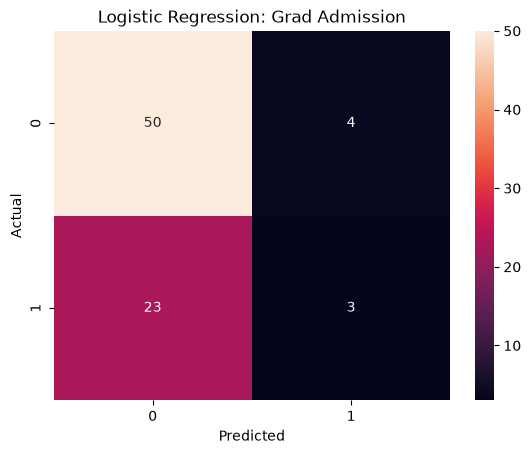

In [17]:
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True, fmt='d').set(title='Logistic Regression: Grad Admission')
plt.show() 

In [18]:
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_[0]})
print(coef_df)
print('\nIntercept:', model.intercept_[0]) 

    Feature  Coefficient
0       gre     0.002717
1       gpa     0.764137
2  prestige    -0.617363

Intercept: -3.549007494364747


In [19]:
sample = pd.DataFrame([[650, 3.6, 2]], columns=feature_cols)
pred_class = model.predict(sample)[0]
pred_prob = model.predict_proba(sample)[0][1]
print(f'Predicted class (1=admit, 0=not admit): {pred_class}')
print(f'Predicted probability of admission: {pred_prob:.3f}') 

Predicted class (1=admit, 0=not admit): 0
Predicted probability of admission: 0.434
